In [492]:
import numpy as np
import scipy
import astropy
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity
from scipy import stats, integrate
from astropy.visualization import hist
from tqdm.notebook import tqdm
import math

the spin is uniformly distributed between 0 and 1.
the mass is normally distributed.
(masses and spins are uncorrelated)

In [4]:
N= 10000
np.random.seed(42) 
spin = stats.uniform.rvs(loc=0, scale=1, size=N) #uniform distribution for spin 
mu = 1 #all the masses are distributed in unit of mu 
mass = scipy.stats.norm.rvs(loc=mu,scale=0.02,size=N)

### production of hist without constrain on the bin 

Text(0.5, 0, 'spin')

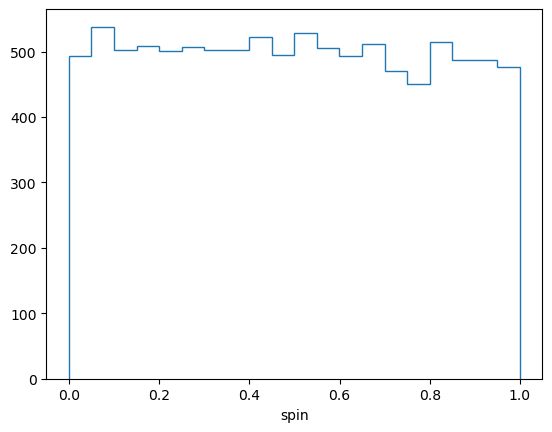

In [7]:
plt.hist(spin, bins=20, histtype="step")
plt.xlabel("spin")

Text(0.5, 0, 'mass')

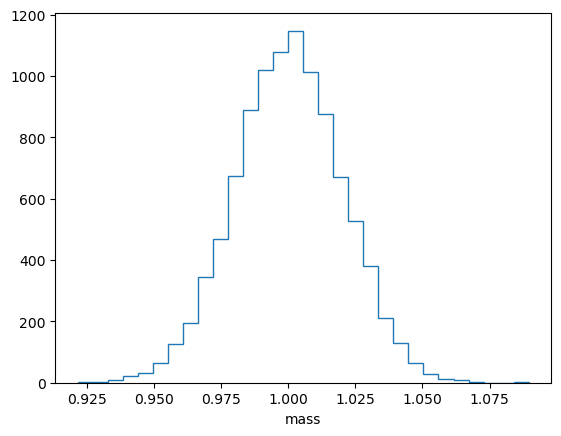

In [9]:
plt.hist(mass, bins=30, histtype="step")
plt.xlabel("mass")

In [11]:
def M_irr(M,S): #definition of irreducible mass
    return np.sqrt((1+np.sqrt(1-S**2))/2)

In [13]:
def f_spin(S):
    return np.sqrt((1+np.sqrt(1-S**2))/2)

In [15]:
def M_irr(M,S): #definition of irreducible mass using function above 
    return M*f_spin(S)

### possible way to visualize an histogram: plotting pdf of the irreducible mass

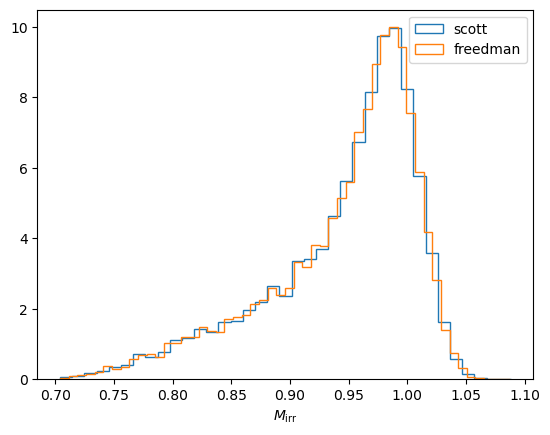

In [18]:
astropy.visualization.hist(M_irr(mass,spin), bins="scott", histtype="step",density=True, label="scott") #when is similar to a gaussian
astropy.visualization.hist(M_irr(mass, spin), bins="freedman", histtype="step",density=True, label="freedman")
plt.xlabel('$M_{\\rm irr}$')
plt.legend()

### plot the distribution of irreducible mass using a KDE 

In [21]:
xgrid = np.linspace(M_irr(mass, spin).min(),M_irr(mass, spin).max(),1000) 

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

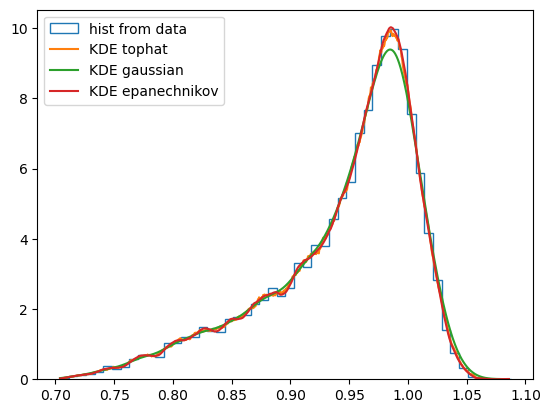

In [23]:
#data
astropy.visualization.hist(M_irr(mass, spin), bins="freedman", histtype="step",density=True, label="hist from data")
#KDE  bandwidth 0.01
PDFtophat = kde_sklearn(M_irr(mass, spin),bandwidth=0.01,kernel="tophat") 
PDFgaussian = kde_sklearn(M_irr(mass, spin),bandwidth=0.01,kernel="gaussian")
PDFep = kde_sklearn(M_irr(mass, spin),bandwidth=0.01,kernel="epanechnikov")
#plot
plt.plot(xgrid,PDFtophat, label="KDE tophat") 
plt.plot(xgrid,PDFgaussian, label="KDE gaussian")
plt.plot(xgrid,PDFep, label="KDE epanechnikov") 
plt.legend()

### KS test

In [26]:
print(stats.ks_2samp(M_irr(mass,spin)/mu, f_spin(spin)))

KstestResult(statistic=0.162, pvalue=6.7099705555812415e-115, statistic_location=0.9999999999830791, statistic_sign=-1)


In [28]:
print(stats.ks_2samp(mass, M_irr(mass,spin)))

KstestResult(statistic=0.4961, pvalue=0.0, statistic_location=0.9763288287138051, statistic_sign=-1)


In [61]:
#sigma = np.linespace(10**-4, 10**4, 40)
sigma = np.logspace(-4,4,40)
result_ks_f = []
result_ks_M = []

for s in sigma:

    mass_s = scipy.stats.norm.rvs(loc=mu,scale=s,size=10000) #generating a gaussian distribution for every sigma
    stat_f, p_f = stats.ks_2samp(f_spin(spin), M_irr(mass_s,spin)/1) #crf with f
    stat_M, p_M = stats.ks_2samp(mass_s, M_irr(mass_s,spin)) #cfr with M
    result_ks_f.append(stat_f)
    result_ks_M.append(stat_M)


In [63]:
#print(result_ks_f)
#print(result_ks_M)

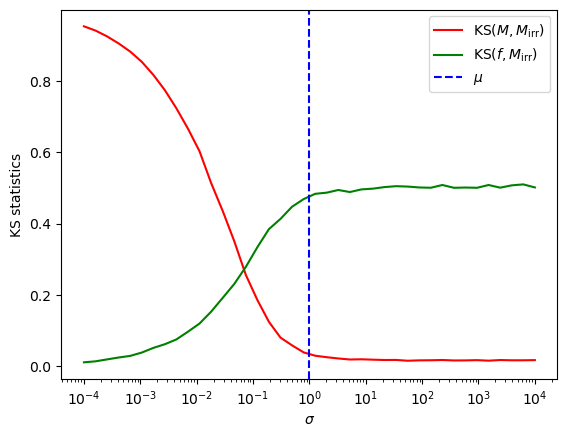

In [69]:
plt.plot(sigma,result_ks_M,label="KS$(M, M_{\\rm irr})$", color="red")
plt.plot(sigma,result_ks_f,label="KS$(f,M_{\\rm irr})$", color="green")
plt.axvline(1, linestyle='--', label=r"$\mu$", color="blue")
plt.xscale('log')
plt.xlabel(r"$\sigma$")
plt.ylabel('KS statistics')
plt.legend()

$M_{irr}$ distributed like $f$ for $\sigma \ll \mu$, so $KS(f, M_{irr})$ goes to zero. \
$M_{irr}$ distributed like $M$ for $\sigma \gg \mu$, so $KS(M, M_{irr})$ goes to zero. 

C:\Users\User\AppData\Local\Temp\ipykernel_23164\1982675418.py:7: RuntimeWarning: divide by zero encountered in divide
  pdf_f = 2*(2*f_integration-1)/np.sqrt(1-f_integration**2)


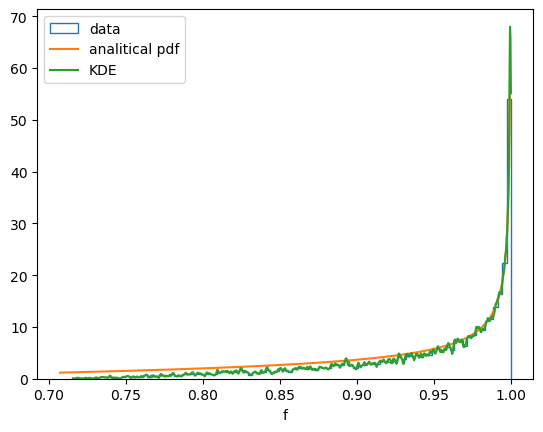

In [424]:
#from data
f = f_spin(spin)
plt.hist(f,density=True, bins=100, histtype='step', label="data")

#analitical computation of the pdf of f 
f_integration = np.linspace(1/2**0.5,1,500, endpoint=True)
pdf_f = 2*(2*f_integration-1)/np.sqrt(1-f_integration**2)
plt.plot(f_integration,pdf_f, label="analitical pdf")
plt.xlabel("f")

#KDE
xgrid = np.linspace(f.min(),f.max(),1000) 
PDFf = kde_sklearn(f,bandwidth=0.001,kernel="epanechnikov")
plt.plot(xgrid,PDFf, label="KDE") 

plt.legend()

In [724]:
#useful quantities
mu = 1 #all the masses are distributed in unit of mu 
mass = scipy.stats.norm.rvs(loc=mu,scale=0.02,size=N)
spin = stats.uniform.rvs(loc=0, scale=1, size=N)
estimated_mirr = np.linspace(1-3*0.02,1+3*0.02,N) #from graph?
mirr = M_irr(mass, f) #note taking the extreme of integration as we know them 

#remember that mass and spin are indipendent

def pdf_Mirr(f_val,mass):
    return ((2/np.pi)**0.5 / 0.02 ) * np.exp(-(M_irr(mass, f_val)/f_val -1)**2 /(2*0.02**2)) * (2*f_val**2-1)/(1 -f_val**2)**0.5 / f_val

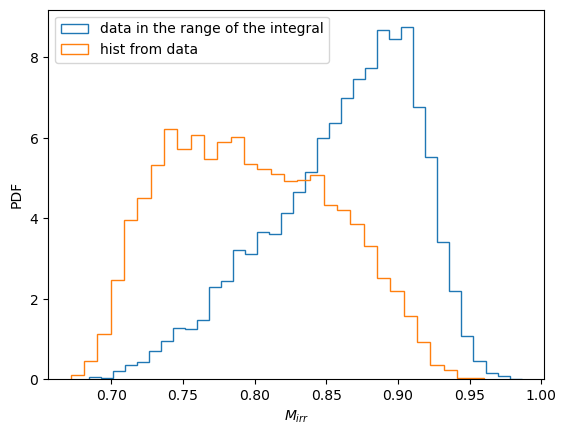

In [728]:
#computing Mirr in the extreme of integration 
Mirr = []
f_grid = np.linspace(1/np.sqrt(2), 1, 10000, endpoint=True) #this is the interval of integration
for f_i,m in zip(f_grid, mass):
    Mirr.append(M_irr(m, f_i))
#print(Mirr)

#plt.hist(Mirr, density=True, bins=30, histtype="step", label="data in the range of the integral")
#plt.hist(mirr,density=True, bins=50, histtype='step', label="data")
astropy.visualization.hist(Mirr, bins="scott", histtype="step",density=True, label="data in the range of the integral")
astropy.visualization.hist(mirr, bins="scott", histtype="step",density=True, label="hist from data")
plt.xlabel(r"$M_{irr}$")
plt.ylabel(r"PDF")
plt.legend()

In [810]:
#def pdf_Mirr(f_val,mass):
    #return ((2/np.pi)**0.5 / 0.02 ) * np.exp(-(M_irr(mass, f_val)/f_val -1)**2 /(2*0.02**2)) * (2*f_val**2-1)/(1 -f_val**2)**0.5 / f_val

Mirr_from_pdf = []

for m in mass:
    integrand = lambda f: pdf_Mirr(f,m)
    I, err = scipy.integrate.quad(integrand, a=(1 / (2**0.5)), b=1)
    Mirr_from_pdf.append(I)

#print(Mirr_from_pdf)

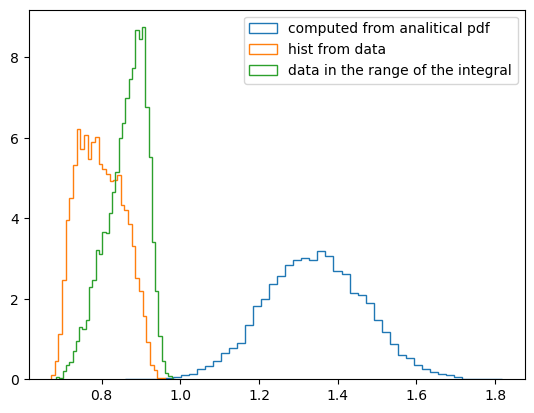

In [740]:
astropy.visualization.hist(Mirr_from_pdf, bins="scott", histtype="step",density=True, label="computed from analitical pdf")
astropy.visualization.hist(mirr, bins="scott", histtype="step",density=True, label="hist from data")
astropy.visualization.hist(Mirr, bins="scott", histtype="step",density=True, label="data in the range of the integral")
#plt.hist(Mirr_from_pdf,bins=100, density=True, label="computed from analitical pdf", histtype="step")
plt.legend()

In [746]:
pdf_f_grid = pdf_Mirr(f_grid,mass)
print(pdf_f_grid)
print(pdf_f_grid[:-1])

[-2.58137931e-79  4.38736996e-43  1.34100440e-52 ...  2.71211567e-49
  5.44985194e-43             inf]
[-2.58137931e-79  4.38736996e-43  1.34100440e-52 ...  2.15123103e-40
  2.71211567e-49  5.44985194e-43]


C:\Users\User\AppData\Local\Temp\ipykernel_23164\1832587904.py:11: RuntimeWarning: divide by zero encountered in divide
  return ((2/np.pi)**0.5 / 0.02 ) * np.exp(-(M_irr(mass, f_val)/f_val -1)**2 /(2*0.02**2)) * (2*f_val**2-1)/(1 -f_val**2)**0.5 / f_val


In [750]:
#initial=0 gives a vector of the same lenght of x (starting from area = 0)
Mirr_from_pdf_trap = integrate.cumulative_trapezoid(y_f_grid, x=f_grid, initial=0)
print(Mirr_from_pdf_trap[:-1])

[0.00000000e+00 2.55850756e-67 4.36314825e-44 ... 1.29331561e+00
 1.29331561e+00 1.29331561e+00]


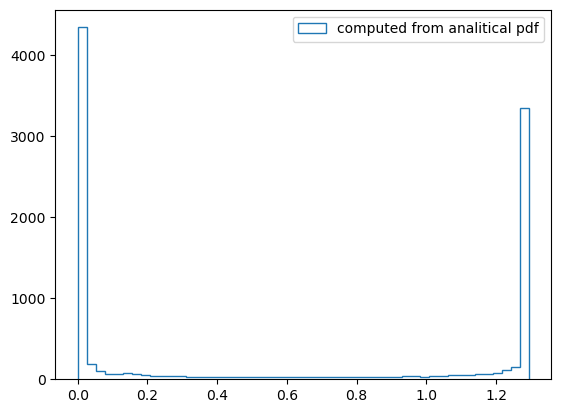

In [754]:
#astropy.visualization.hist(Mirr_from_pdf_trap[:-1], bins="scott", histtype="step",density=True, label="computed from analitical pdf")
plt.hist(Mirr_from_pdf_trap[:-1],bins=50, label="computed from analitical pdf", histtype="step")
plt.legend()

C:\Users\User\AppData\Local\Temp\ipykernel_23164\1832587904.py:11: RuntimeWarning: divide by zero encountered in divide
  return ((2/np.pi)**0.5 / 0.02 ) * np.exp(-(M_irr(mass, f_val)/f_val -1)**2 /(2*0.02**2)) * (2*f_val**2-1)/(1 -f_val**2)**0.5 / f_val


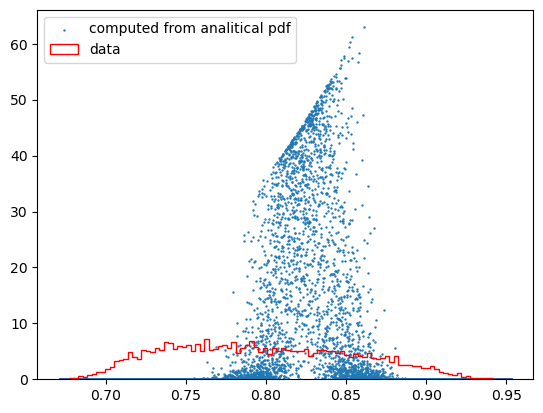

In [808]:
x_plot =  np.linspace(mirr.min(),mirr.max(),10000) 
pdf_f_grid = pdf_Mirr(f_grid,mass)
pdf_f_grid_sort = pdf_f_grid 
plt.scatter(x_plot[:-1],pdf_f_grid_sort[:-1], label="computed from analitical pdf", s=0.5)
plt.hist(mirr,density=True, bins=100, histtype='step', label="data", color="red")
plt.legend()

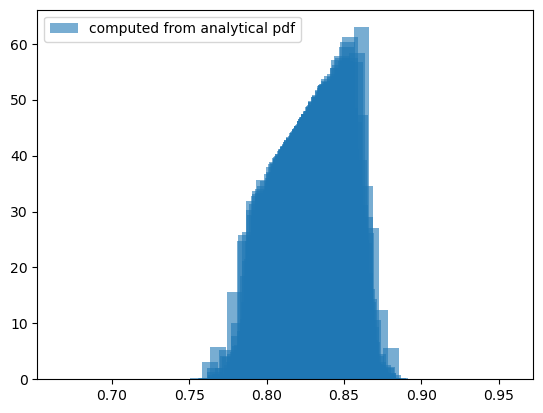

In [820]:
plt.bar(x_plot[:-1], pdf_f_grid[:-1], width=0.01,alpha=0.6, label="computed from analytical pdf")
plt.legend()